# Preprocessing dan Ekstraksi Fitur TSFEL NO2

## Kecamatan Menganti, Kabupaten Gresik

Notebook ini digunakan untuk melakukan preprocessing data time series NO2 sebelum dilakukan ekstraksi fitur menggunakan Time Series Feature Extraction Library (TSFEL).

Tahapan preprocessing meliputi:

1. Memuat data NO2 Kecamatan Menganti.
2. Memeriksa kondisi awal data.
3. Mendeteksi outlier menggunakan metode Interquartile Range (IQR).
4. Mengubah nilai outlier menjadi missing value.
5. Melakukan imputasi missing value berdasarkan urutan waktu.
6. Memastikan seluruh data NO2 telah terisi.
7. Menyiapkan data untuk ekstraksi 68 fitur TSFEL.

## 1. Informasi Dataset

Data yang digunakan merupakan data harian konsentrasi NO2 hasil pengolahan Sentinel-5P untuk wilayah Kecamatan Menganti, Kabupaten Gresik.

**Informasi data:**

- Wilayah: Kecamatan Menganti
- Kabupaten: Gresik
- Kode BPS Kecamatan: 3525040
- Periode: 31-08-2025 sampai 31-08-2026
- Jumlah observasi: 366 hari
- Fitur yang digunakan untuk ekstraksi: NO2

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tsfel
import tsfel.feature_extraction.features as tsfel_features
import inspect

DATA_PATH = "../data/processed/menganti_NO2_daily.csv"

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,NO2
0,2025-08-31,0.000029
1,2025-09-01,0.000029
2,2025-09-02,0.000021
3,2025-09-03,0.000032
4,2025-09-04,0.000041


In [79]:
print("Jumlah baris:", len(df))
print("Jumlah kolom:", len(df.columns))

print("\nKolom:")
print(df.columns.tolist())

print("\nTanggal:")
print("Awal :", df["date"].min().date())
print("Akhir:", df["date"].max().date())

print("\nTipe data:")
print(df.dtypes)

Jumlah baris: 366
Jumlah kolom: 2

Kolom:
['date', 'NO2']

Tanggal:
Awal : 2025-08-31
Akhir: 2026-08-31

Tipe data:
date    datetime64[us]
NO2            float64
dtype: object


## 2. Pemeriksaan Missing Value

Pada data awal masih terdapat nilai NO2 yang kosong. Missing value perlu ditangani sebelum proses ekstraksi fitur TSFEL karena seluruh sinyal harus tersedia sebagai deret numerik.

In [80]:
missing_before = df["NO2"].isna().sum()

print("Missing value NO2:", missing_before)
print("Data valid:", df["NO2"].notna().sum())

Missing value NO2: 151
Data valid: 215


## 3. Deteksi Outlier Menggunakan IQR

Deteksi outlier dilakukan menggunakan metode Interquartile Range (IQR).

Rumus:

$$
IQR = Q_3 - Q_1
$$

Batas bawah:

$$
LB = Q_1 - 1.5(IQR)
$$

Batas atas:

$$
UB = Q_3 + 1.5(IQR)
$$

Nilai dikategorikan sebagai kandidat outlier apabila:

$$
x < LB
\quad \text{atau} \quad
x > UB
$$

In [81]:
Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1          : {Q1:.12e}")
print(f"Q3          : {Q3:.12e}")
print(f"IQR         : {IQR:.12e}")
print(f"Batas bawah : {lower_bound:.12e}")
print(f"Batas atas  : {upper_bound:.12e}")

Q1          : 3.387142743512e-05
Q3          : 6.328581999912e-05
IQR         : 2.941439256400e-05
Batas bawah : -1.025016141088e-05
Batas atas  : 1.074074088451e-04


In [82]:
outlier_mask = (
    (df["NO2"] < lower_bound) |
    (df["NO2"] > upper_bound)
)

outliers = df.loc[outlier_mask, ["date", "NO2"]].copy()

print("Jumlah outlier:", len(outliers))

outliers

Jumlah outlier: 4


,date,NO2
20,2025-09-20,0.000113
23,2025-09-23,0.000160
24,2025-09-24,0.000125
264,2026-05-22,0.000160


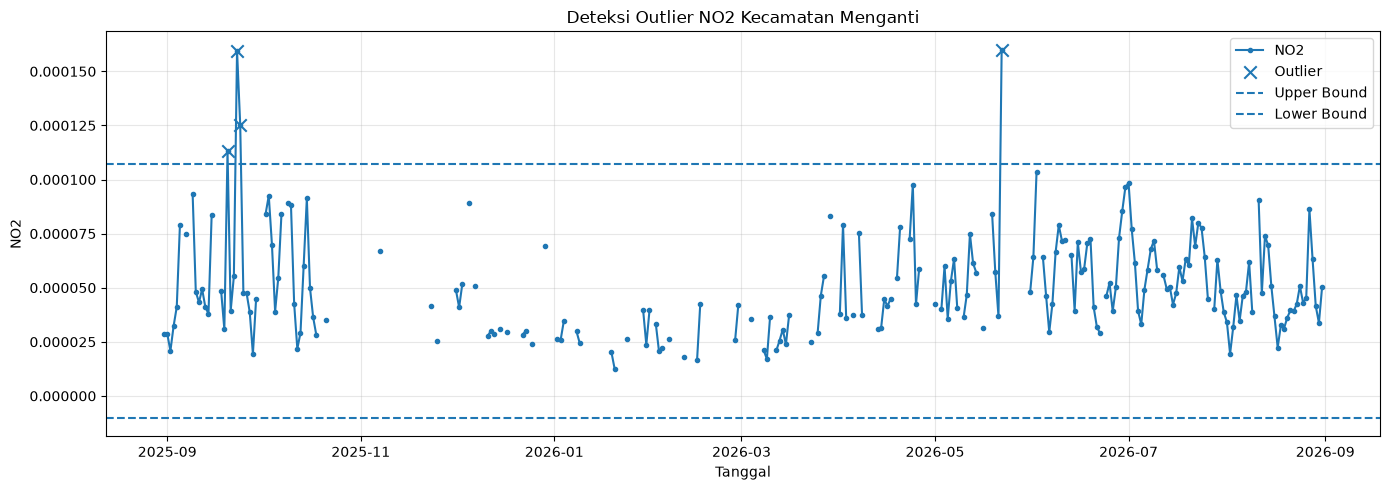

In [83]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["NO2"],
    marker=".",
    linestyle="-",
    label="NO2"
)

plt.scatter(
    outliers["date"],
    outliers["NO2"],
    marker="x",
    s=80,
    label="Outlier"
)

plt.axhline(
    upper_bound,
    linestyle="--",
    label="Upper Bound"
)

plt.axhline(
    lower_bound,
    linestyle="--",
    label="Lower Bound"
)

plt.title("Deteksi Outlier NO2 Kecamatan Menganti")
plt.xlabel("Tanggal")
plt.ylabel("NO2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 4. Penanganan Outlier

Nilai yang teridentifikasi sebagai outlier tidak langsung menghapus baris data. Nilai NO2 yang berada di luar batas IQR diubah menjadi `NaN`.

Dengan demikian, jumlah observasi dan urutan tanggal tetap dipertahankan. Nilai tersebut kemudian akan diperlakukan bersama missing value pada tahap imputasi.

In [84]:
df_preprocessed = df.copy()

df_preprocessed.loc[
    outlier_mask,
    "NO2"
] = np.nan

print(
    "Missing setelah outlier dijadikan NaN:",
    df_preprocessed["NO2"].isna().sum()
)

Missing setelah outlier dijadikan NaN: 155


## 5. Imputasi Missing Value

Missing value diisi menggunakan interpolasi berdasarkan waktu.

Karena data merupakan time series harian, indeks tanggal digunakan sebagai dasar interpolasi.

Tahapan imputasi mengikuti urutan:

1. Interpolasi berdasarkan waktu.
2. `ffill()` untuk mengisi missing value yang masih berada di bagian awal atau celah yang belum terisi.
3. `bfill()` untuk mengisi missing value yang masih tersisa di bagian akhir.

In [85]:
print("Missing sebelum preprocessing :", df["NO2"].isna().sum())

# Hitung missing setelah outlier dijadikan NaN
missing_after_outlier = df_preprocessed["NO2"].isna().sum()

print("Missing setelah outlier       :", missing_after_outlier)

# Jadikan tanggal sebagai index terlebih dahulu
df_preprocessed = df_preprocessed.set_index("date")

# Imputasi missing value berdasarkan waktu
df_preprocessed["NO2"] = (
    df_preprocessed["NO2"]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

# Kembalikan date menjadi kolom
df_preprocessed = df_preprocessed.reset_index()

# Cek hasil imputasi
missing_after = df_preprocessed["NO2"].isna().sum()

print("Missing setelah imputasi      :", missing_after)

Missing sebelum preprocessing : 151
Missing setelah outlier       : 155
Missing setelah imputasi      : 0


In [86]:
print("=== VALIDASI PREPROCESSING ===")
print("Jumlah baris :", len(df_preprocessed))
print("NO2 missing  :", df_preprocessed["NO2"].isna().sum())
print("NO2 valid    :", df_preprocessed["NO2"].notna().sum())
print("Tanggal awal :", df_preprocessed["date"].min().date())
print("Tanggal akhir:", df_preprocessed["date"].max().date())

=== VALIDASI PREPROCESSING ===
Jumlah baris : 366
NO2 missing  : 0
NO2 valid    : 366
Tanggal awal : 2025-08-31
Tanggal akhir: 2026-08-31


In [87]:
PREPROCESSED_PATH = "../data/processed/menganti_NO2_preprocessed.csv"

df_preprocessed.to_csv(
    PREPROCESSED_PATH,
    index=False
)

print("File preprocessing disimpan di:")
print(PREPROCESSED_PATH)

File preprocessing disimpan di:
../data/processed/menganti_NO2_preprocessed.csv


## 6. Ekstraksi Fitur TSFEL

Data NO2 yang telah melalui preprocessing dan tidak lagi memiliki missing value selanjutnya digunakan sebagai input ekstraksi fitur menggunakan Time Series Feature Extraction Library (TSFEL).

Ekstraksi dilakukan menggunakan daftar 68 fitur yang telah ditentukan oleh komting. Daftar fitur dan mekanisme ekstraksi tidak diubah agar file hasil akhir tetap sesuai dengan ketentuan tugas.

### Daftar 68 Fitur TSFEL

Ekstraksi fitur menggunakan daftar fitur yang telah ditentukan oleh komting. Daftar fitur dipertahankan tanpa perubahan agar format hasil ekstraksi sesuai dengan ketentuan tugas.

In [88]:
fs = 1

signal_1d = (
    df_preprocessed["NO2"]
    .astype(float)
    .values
)

print("Jumlah titik data:", len(signal_1d))
print("Missing value:", np.isnan(signal_1d).sum())

Jumlah titik data: 366
Missing value: 0


In [89]:
# ---------- Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))

Jumlah fitur yang diminta: 68


In [90]:
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]

    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))

    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters

    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)

    return to_scalar(result)

In [91]:
row = {}

for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(
        fn_name,
        signal_1d,
        fs
    )

extracted_features_final = pd.DataFrame([row])

print(
    "Berhasil! Jumlah fitur yang dihasilkan untuk NO2:",
    extracted_features_final.shape[1]
)

Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


### Menyimpan Hasil Ekstraksi Fitur

Hasil ekstraksi disimpan dalam format CSV. File hasil ekstraksi ini merupakan file final untuk dikirim dan tidak dilakukan perubahan manual terhadap isi maupun strukturnya.

In [92]:
OUTPUT_FEATURE_PATH = "../data/features/NO2_Menganti_TSFEL.csv"

extracted_features_final.to_csv(
    OUTPUT_FEATURE_PATH,
    index=False
)

print("File hasil ekstraksi:")
print(OUTPUT_FEATURE_PATH)

File hasil ekstraksi:
../data/features/NO2_Menganti_TSFEL.csv
